# Winter

## Script to process multiple years to find the winter like and summer like days, and the warmest and coldest day

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import warnings
warnings.filterwarnings('ignore')



In [113]:
###################
# helper functions
###################
def WinterSummerDays(temp_data, temp_data_next, winter_threshold, summer_threshold, show_plot):
    '''

    Function that uses the input 25th and 75th percentile temperature in K to identify summer-like and winter-like days and Tmin day from a time series of temperatures.
    Input data should already be set to 365 days.

    Args:
        temp_data: xarray of temperature data for a single grid cell for the year of interest
        temp_data_next: xarray of temperature data for a single grid cell for the following year (for NH winters, SH summers)
        winter_threshold: xarray for the 25th percentile threshold to use
        summer_threshold: xarray for the 75th percentile threshold to use
        show_plots: boolean for whether to plot the summer and winter time series with the labeled WLD and SLD, max and min
        
    Returns:
        first WLD: first DOY that daily mean t2m is below winter threshold (25th percentile)
        last WLD: last DOY that daily mean t2m is below winter threshold (25th percentile)
        first SLD: first DOY that daily mean t2m is above summer threshold (75th percentile)
        last SLD: last DOY that daily mean t2m is above summer threshold (75th percentile)
        day with max temp: the DOY that had the highest mean daily t2m 
        tmax value: temp in [K] for day of max temp
        day with min temp: the DOY that had the lowest mean daily t2m
        tmin value: temp in [K] for day of min temp
        winterlike days: number of days in the 12 month period that had a mean T2m <= the winter threshold
        summerlike days: number of days in the 12 month period that had a mean T2m >= the summer threshold
        
    Example:
        first_wld, last_wld, first_sld, last_sld, day_of_max, tmax, day_of_min, tmin, winterlike_days, summerlike_days = WinterSummerDays(temps, temps_next, winter_threshold, summer_threshold, True)

    '''

    # default values
    first_wld = 0 
    last_wld = 0
    first_sld = 0 
    last_sld = 0
    tmax_day = 0 
    tmax = 0
    tmin_day = 0 
    tmin = 0
    winter_like_days = 0
    summer_like_days = 0

    # split method based on NH or SH
    # WLD should be counted and indexed over the cycle with winter at the center to see trends over time
    # otherwise the first WLD will nearly always be day 1 of the year in the NH 
    # similarly for SLD in the SH we want the summer months of DJF to be in the center of the cycle

    # extract DOY and T2m values for those days from just the current year
    x1_cur = temp_data.time.dt.dayofyear.values
    y1_cur = temp_data.values

    # same but for current plus next for SH summer and NH winter
    ds_two = xr.concat([temp_data, temp_data_next], dim="time")

    # get the current year for slicing
    input_year = temp_data.time.dt.year.values[0]

    # select July 1 - June 30 across the two years to do fit
    startdate = str(input_year)+'-07-01' # 182nd day of a normal year
    enddate = str(input_year+1)+'-06-30'
    offset_yr = ds_two.sel(time=slice(startdate,enddate))
    
    # DOY (relative to July 1) and T2m values for those days
    x1_off = np.arange(1,len(offset_yr.time)+1) 
    y1_off = offset_yr.values

    ######
    # Southern Hemisphere 
    ######
    if temp_data.lat.values < 0:
        ########
        # Winter uses current year only

        # count of winter-like days in the year (any time during the year)
        # and the first/last occurence where the winter months (JJA) are centered in the cycle
        winter_like_days = np.where(y1_cur <= winter_threshold.values)[0].size

        # handle the case where NO days are below the threshold for winter
        if winter_like_days > 0:
            first_wld = np.where(y1_cur <= winter_threshold.values)[0][0] + 1 # +1 because zero-indexing in python
            last_wld = np.where(y1_cur <= winter_threshold.values)[0][-1] + 1

        # tmin day is determined in winter "year"
        tmin_day = int(temp_data.argmin() + 1)
        tmin = y1_cur.min()


        ########
        # Summer uses current year and next year

        # count of summer-like days in the year (any time during the "year)"
        # and the first/last occurence where the summer months (DJF) are centered in the cycle
        summer_like_days = np.where(y1_off >= summer_threshold.values)[0].size

        # handle the case where no days are above summer threshold (seems unlikely but just in case)
        if summer_like_days > 0:
            first_sld = np.where(y1_off >= summer_threshold.values)[0][0] + 1 # +1 because zero-indexing in python
            last_sld = np.where(y1_off >= summer_threshold.values)[0][-1] + 1

        # tmax day is determined in summer "year"
        tmax_day = int(offset_yr.argmax() + 1)
        tmax = y1_off.max()

        # create some x values for plotting  fit
        #x_values = np.linspace(min(x1), max(x1), 365)

        if show_plot:
            fs = 8
            cell_lat = temp_data.lat.values
            cell_lon = temp_data.lon.values
            yr = temp_data.time.dt.year.values[0]
            
            fig = plt.figure(figsize=(16,5), layout='constrained')
            # SH winter
            ax1 = fig.add_subplot(1,2,1)
            ax1.plot(x1_cur,y1_cur, label='daily mean T2m')
            ax1.axhline(winter_threshold, color="black", linewidth=0.8, linestyle="dashed")
            ax1.annotate('first WLD', xy=(first_wld,np.min(y1_cur)), fontsize=fs, 
                         arrowprops = dict(facecolor ='green', shrink = 0.05))
            ax1.annotate('last WLD', xy=(last_wld,np.min(y1_cur)), fontsize=fs, 
                         arrowprops = dict(facecolor ='green', shrink = 0.05))
            ax1.annotate('Tmin day '+str(tmin_day)+'\n'+str(np.round(tmin,1))+'K', xy=(tmin_day,np.min(y1_cur)), fontsize=fs, 
                         arrowprops = dict(facecolor ='black', shrink = 0.05))
            ax1.annotate('25th percentile = '+str(np.round(winter_threshold.values,1))+'K', xy=(0,winter_threshold.values+1), fontsize=fs+2)
            ax1.set_xlabel('DOY (' + str(yr) + ')')
            ax1.set_ylabel('Mean Daily Temp (K)')
            ax1.set_title(str(yr) + " Winter for Lat,Lon = [" +str(cell_lat)+","+str(cell_lon)+ "] Baseline Years = (1961-1990)")

            # SH Summer
            ax2 = fig.add_subplot(1,2,2)
            ax2.plot(x1_off,y1_off, label='daily mean T2m')
            ax2.axhline(summer_threshold, color="black", linewidth=0.8, linestyle="dashed")
            ax2.annotate('first SLD', xy=(first_sld,np.min(y1_off)), fontsize=fs, 
                         arrowprops = dict(facecolor ='red', shrink = 0.05))
            ax2.annotate('last SLD', xy=(last_sld,np.min(y1_off)), fontsize=fs, 
                         arrowprops = dict(facecolor ='red', shrink = 0.05))
            ax2.annotate('Tmax day '+str(tmax_day)+'\n'+str(np.round(tmax,1))+'K', xy=(tmax_day,np.min(y1_off)), fontsize=fs, 
                         arrowprops = dict(facecolor ='black', shrink = 0.05))
            ax2.annotate('75th percentile = '+str(np.round(summer_threshold.values,1))+'K', xy=(0,summer_threshold.values+1), fontsize=fs+2)
            ax2.set_xlabel('DOY (' + str(yr) + ') relative to July 1')
            ax2.set_ylabel('Mean Daily Temp (K)')
            ax2.set_title(str(yr) + " Summer for Lat,Lon = [" +str(cell_lat)+","+str(cell_lon)+ "] Baseline Years = (1961-1990)")
            plt.show()
    
    ######
    # Northern Hemisphere 
    # winter uses current year and following year
    else: 

        # Winter
        # count of winter-like days in the year (any time during the year)
        # and the first/last occurence where the winter months (DJF) are centered in the cycle
        winter_like_days = np.where(y1_off <= winter_threshold.values)[0].size

        # handle the case where NO days are below the threshold for winter
        if winter_like_days > 0:
            first_wld = np.where(y1_off <= winter_threshold.values)[0][0] + 1 # +1 because zero-indexing in python
            last_wld = np.where(y1_off <= winter_threshold.values)[0][-1] + 1

        # tmin day is determined in winter "year"
        tmin_day = int(offset_yr.argmin() + 1)
        tmin = y1_off.min()

        # Summer
        
        # count of summer-like days in the year (any time during the year)
        # and the first/last occurence where the summer months (JJA) are centered in the cycle
        summer_like_days = np.where(y1_cur >= summer_threshold.values)[0].size

        # handle the case where no days are above summer threshold (seems unlikely but just in case)
        if summer_like_days > 0:
            first_sld = np.where(y1_cur >= summer_threshold.values)[0][0] + 1 # +1 because zero-indexing in python
            last_sld = np.where(y1_cur >= summer_threshold.values)[0][-1] + 1

        # tmax day is determined in summer "year"
        tmax_day = int(temp_data.argmax() + 1)
        tmax = y1_cur.max()
                
        if show_plot:
            fs = 8
            cell_lat = temp_data.lat.values
            cell_lon = temp_data.lon.values
            yr = temp_data.time.dt.year.values[0]
            
            fig = plt.figure(figsize=(16,5), layout='constrained')
            # NH Winter
            ax1 = fig.add_subplot(1,2,1)
            ax1.plot(x1_off,y1_off, label='daily mean T2m')
            ax1.axhline(winter_threshold, color="black", linewidth=0.8, linestyle="dashed")
            ax1.annotate('first WLD', xy=(first_wld,np.min(y1_off)), fontsize=fs, 
                         arrowprops = dict(facecolor ='green', shrink = 0.05))
            ax1.annotate('last WLD', xy=(last_wld,np.min(y1_off)), fontsize=fs, 
                         arrowprops = dict(facecolor ='green', shrink = 0.05))
            ax1.annotate('Tmin day '+str(tmin_day)+'\n'+str(np.round(tmin,1))+'K', xy=(tmin_day,np.min(y1_off)), fontsize=fs, 
                         arrowprops = dict(facecolor ='black', shrink = 0.05))
            ax1.annotate('25th percentile = '+str(np.round(winter_threshold.values,1))+'K', xy=(0,winter_threshold.values+1), fontsize=fs+2)
            ax1.set_xlabel('DOY (' + str(yr) + ') relative to July 1')
            ax1.set_ylabel('Mean Daily Temp (K)')
            ax1.set_title(str(yr) + " Winter for Lat,Lon = [" +str(cell_lat)+","+str(cell_lon)+ "] Baseline Years = (1961-1990)")

            # NH Summer
            ax2 = fig.add_subplot(1,2,2)
            ax2.plot(x1_cur,y1_cur, label='daily mean T2m')
            ax2.axhline(summer_threshold, color="black", linewidth=0.8, linestyle="dashed")
            ax2.annotate('first SLD', xy=(first_sld,np.min(y1_cur)), fontsize=fs, 
                         arrowprops = dict(facecolor ='red', shrink = 0.05))
            ax2.annotate('last SLD', xy=(last_sld,np.min(y1_cur)), fontsize=fs, 
                         arrowprops = dict(facecolor ='red', shrink = 0.05))
            ax2.annotate('Tmax day '+str(tmax_day)+'\n'+str(np.round(tmax,1))+'K', xy=(tmax_day,np.min(y1_cur)), fontsize=fs, 
                         arrowprops = dict(facecolor ='black', shrink = 0.05))
            ax2.annotate('75th percentile = '+str(np.round(summer_threshold.values,1))+'K', xy=(0,summer_threshold.values+1), fontsize=fs+2)
            ax2.set_xlabel('DOY (' + str(yr) + ')')
            ax2.set_ylabel('Mean Daily Temp (K)')
            ax2.set_title(str(yr) + " Summer for Lat,Lon = [" +str(cell_lat)+","+str(cell_lon)+ "] Baseline Years = (1961-1990)")
            plt.show()       
    
    # return
    return int(first_wld), int(last_wld), int(first_sld), int(last_sld), int(tmax_day), float(tmax), int(tmin_day), float(tmin), int(winter_like_days), int(summer_like_days)
    




In [40]:
# a function that takes in a dataset of global t2m values and if it is a leap year averages
# the temps on Feb 28 & Feb 29, then drops Feb 29 to ensure the year has 365 days
def HandleLeapYears(input_ds):
    '''

    Function that takes the mean of Feb 28 & Feb 29 (if it exists) and returns an xarray Dataset that has 365 days
    where Feb 28 will now have a t2m value that is the mean of Feb 28 & Feb 29

    Args:
        input_ds: the data set containing a single year of data that may need adjusting for leap year
        
    Returns:
        output_ds
        
    Example:
        no_leap_ds = HandleLeapYears(input_ds)

    '''
    

    # check if a leap year
    if(input_ds.time.dt.is_leap_year[0].values):
        
        # make deep copy
        output_ds = input_ds.copy(deep=True)
        
        # get mean of Feb 28 (time index 58) & Feb 29 (time index 59) for each grid cell and overwrite Feb 28 with it
        mean_dat = output_ds.t2m[58:60].mean(dim='time', skipna=True, keep_attrs=True)
        output_ds.t2m[58] = mean_dat
        
        # drop Feb 29
        output_ds = output_ds.convert_calendar('noleap', use_cftime=None)

        # ensure time is datetime64
        output_ds["time"] = output_ds.time.dt.strftime('%Y-%m-%d')
        output_ds['time'] = pd.to_datetime(output_ds['time'])

        # return the new dataset 
        return output_ds
    else:
        return input_ds
    

## Load baseline 25th percentile and 75th temps per grid cell

In [41]:
# get baseline winter temps
file_path = '../../../../Data/ERA5-global/Baseline/computed_1961-1990-full_25th.nc'
c_25 = xr.open_dataarray(file_path)
c_25.values


array([[218.86286926, 218.86286926, 218.86286926, ..., 218.86286926,
        218.86286926, 218.86286926],
       [218.52233887, 218.52339172, 218.52293396, ..., 218.51637268,
        218.51916504, 218.52043152],
       [218.57655334, 218.57861328, 218.58085632, ..., 218.56170654,
        218.56726074, 218.57206726],
       ...,
       [246.8707428 , 246.86950684, 246.86828613, ..., 246.86943054,
        246.86888123, 246.86985779],
       [246.88891602, 246.88896179, 246.88874817, ..., 246.8840332 ,
        246.88557434, 246.88737488],
       [246.99066162, 246.99066162, 246.99066162, ..., 246.99066162,
        246.99066162, 246.99066162]], shape=(721, 1440))

In [42]:
file_path = '../../../../Data/ERA5-global/Baseline/computed_1961-1990-full_75th.nc'
c_75 = xr.open_dataarray(file_path)
c_75.values

array([[236.4370575 , 236.4370575 , 236.4370575 , ..., 236.4370575 ,
        236.4370575 , 236.4370575 ],
       [236.18743896, 236.1893158 , 236.19142151, ..., 236.18388367,
        236.18530273, 236.18659973],
       [235.91021729, 235.9200592 , 235.92704773, ..., 235.88049316,
        235.8903656 , 235.90020752],
       ...,
       [270.7281189 , 270.72640991, 270.72720337, ..., 270.73239136,
        270.73184204, 270.73007202],
       [270.74356079, 270.74273682, 270.74200439, ..., 270.74594116,
        270.74508667, 270.74420166],
       [270.7550354 , 270.7550354 , 270.7550354 , ..., 270.7550354 ,
        270.7550354 , 270.7550354 ]], shape=(721, 1440))

## Load data for testing

In [44]:
%%time
input_year = 2025

# get this year and next year's daily mean t2m data
if input_year <= 1990:
    file_path = '../../../../Data/ERA5-global/Baseline/' + str(input_year) + '/download_daily_mean_2m*.nc'
else:
    file_path = '../../../../Data/ERA5-global/Analysis/' + str(input_year) + '/download_daily_mean_2m*.nc'
ds = xr.open_mfdataset(file_path)

if input_year+1 <= 1990:
    file_path_next = '../../../../Data/ERA5-global/Baseline/' + str(input_year+1) + '/download_daily_mean_2m*.nc'
else:
    file_path_next = '../../../../Data/ERA5-global/Analysis/' + str(input_year+1) + '/download_daily_mean_2m*.nc'
dsnext = xr.open_mfdataset(file_path_next)

# remove leap day by averaging Feb 28 & 29 together before dropping Feb 29
ds = HandleLeapYears(ds)
dsnext = HandleLeapYears(dsnext)

# load into memory to speed up the summer stats processing
ds.load()
dsnext.load()

#test for Vancouver
input_lat = 49.246
input_lon = -123.116
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")

CPU times: user 6.39 s, sys: 1.89 s, total: 8.28 s
Wall time: 8.58 s


In [8]:
curr, nxt

(<xarray.DataArray 't2m' (time: 365)> Size: 1kB
 array([276.6951 , 276.22052, 276.72952, 277.898  , 279.25354, 277.80075,
        277.01038, 278.59402, 278.1579 , 278.70956, 277.91776, 277.20947,
        275.25574, 275.60376, 276.14816, 276.71945, 276.31876, 274.92038,
        275.189  , 273.6929 , 273.69168, 273.79477, 273.9044 , 275.38882,
        274.74496, 274.18466, 274.01566, 273.9949 , 274.0247 , 275.33893,
        276.5571 , 275.1525 , 272.60065, 269.72815, 269.01886, 269.15082,
        269.84875, 269.18106, 271.6113 , 272.11932, 269.89584, 267.2565 ,
        268.79605, 270.81418, 272.44083, 274.8311 , 276.0026 , 277.57803,
        278.17453, 279.9139 , 279.82913, 278.89426, 280.52365, 281.87143,
        280.88315, 280.3689 , 280.99292, 281.45026, 281.9111 , 281.56674,
        280.94675, 280.79218, 280.22348, 278.7042 , 277.9251 , 278.19888,
        279.02777, 280.422  , 277.0389 , 277.17468, 278.35095, 278.41235,
        276.4575 , 277.2001 , 277.76566, 277.837  , 277.14966, 2

## Adding count of "winter-like" days - testing

In [10]:
curr

<xarray.DataArray 't2m' (time: 365)> Size: 1kB
array([276.6951 , 276.22052, 276.72952, 277.898  , 279.25354, 277.80075,
       277.01038, 278.59402, 278.1579 , 278.70956, 277.91776, 277.20947,
       275.25574, 275.60376, 276.14816, 276.71945, 276.31876, 274.92038,
       275.189  , 273.6929 , 273.69168, 273.79477, 273.9044 , 275.38882,
       274.74496, 274.18466, 274.01566, 273.9949 , 274.0247 , 275.33893,
       276.5571 , 275.1525 , 272.60065, 269.72815, 269.01886, 269.15082,
       269.84875, 269.18106, 271.6113 , 272.11932, 269.89584, 267.2565 ,
       268.79605, 270.81418, 272.44083, 274.8311 , 276.0026 , 277.57803,
       278.17453, 279.9139 , 279.82913, 278.89426, 280.52365, 281.87143,
       280.88315, 280.3689 , 280.99292, 281.45026, 281.9111 , 281.56674,
       280.94675, 280.79218, 280.22348, 278.7042 , 277.9251 , 278.19888,
       279.02777, 280.422  , 277.0389 , 277.17468, 278.35095, 278.41235,
       276.4575 , 277.2001 , 277.76566, 277.837  , 277.14966, 278.95026,
       278.99127, 278.7128 , 277.41586, 278.24924, 281.51376, 283.02197,
       283.85745, 284.02597, 281.89032, 280.48303, 280.38403, 282.06918,
       280.8173 , 280.38092, 279.6708 , 280.85422, 283.36588, 284.48273,
       282.37134, 280.51202, 281.36597, 283.19254, 281.46402, 280.04892,
       279.92032, 282.42838, 282.62967, 282.92035, 282.89993, 283.64346,
       283.47342, 281.7723 , 280.9005 , 280.822  , 282.1152 , 284.04526,
       286.0271 , 285.28717, 283.5827 , 282.82446, 283.0908 , 283.25845,
...
       290.0798 , 288.86734, 288.77255, 289.3364 , 288.8027 , 287.97647,
       290.2555 , 292.65253, 289.12933, 287.89444, 288.62076, 288.58444,
       286.30966, 288.39047, 288.32053, 286.09082, 285.09903, 287.3293 ,
       287.31317, 288.1563 , 286.9283 , 286.40308, 286.21622, 284.6168 ,
       285.03375, 284.94168, 284.9    , 285.53833, 284.89517, 284.53928,
       283.7473 , 283.82193, 282.28162, 281.61823, 280.34912, 280.72067,
       280.5342 , 283.32388, 281.3087 , 282.01544, 281.79636, 283.26617,
       282.02414, 283.8707 , 285.16678, 281.39615, 280.90958, 279.33878,
       279.05197, 282.55716, 280.86978, 280.65884, 282.84985, 280.74182,
       280.46542, 279.10684, 282.72366, 283.31183, 282.19553, 280.09177,
       282.5738 , 284.65286, 281.02933, 280.12228, 282.83267, 279.5544 ,
       280.4327 , 282.69702, 282.50333, 279.31522, 277.95865, 280.0103 ,
       280.15018, 281.5276 , 281.63705, 277.1027 , 277.45523, 278.85135,
       279.7712 , 279.49637, 277.2313 , 275.512  , 276.38528, 277.69238,
       278.14426, 278.5706 , 279.15967, 281.07608, 280.47437, 281.16718,
       281.4092 , 280.17352, 281.34616, 279.5737 , 281.0927 , 282.2049 ,
       284.02744, 280.577  , 280.41217, 278.50345, 277.03915, 277.28098,
       278.2698 , 277.30423, 276.8251 , 276.9952 , 276.16196, 276.2432 ,
       274.77628, 273.3834 , 275.40182, 276.11588, 276.2548 ],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2025-01-01 2025-01-02 ... 2025-12-31
    lat      float64 8B 49.25
    lon      float64 8B -123.0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [35]:
winter_thresh = c_25.sel(lat=input_lat, lon=input_lon, method="nearest").values
summer_thresh = c_75.sel(lat=input_lat, lon=input_lon, method="nearest").values
winter_thresh, summer_thresh

(array(277.37149048), array(286.88796997))

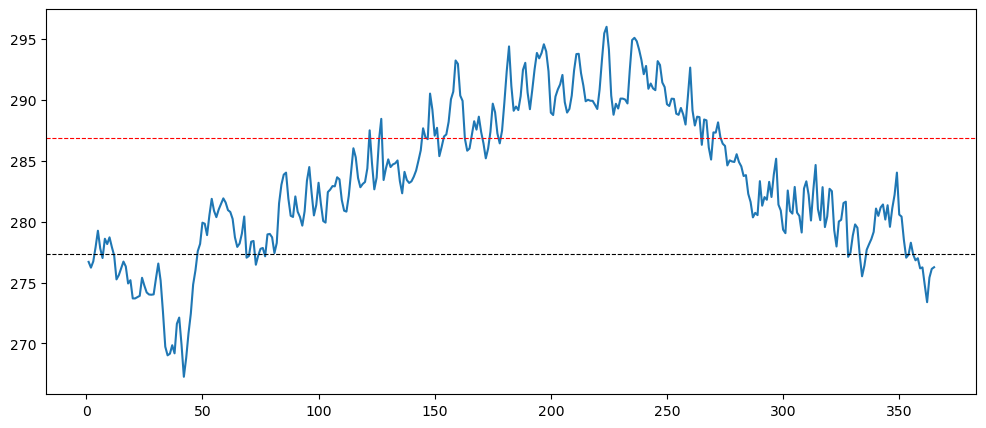

In [36]:
x1 = curr.time.dt.dayofyear.values
y1 = curr.values

plt.figure(figsize=(12,5))
plt.plot(x1,y1, label='daily mean T2m')
plt.axhline(winter_thresh, color="black", linewidth=0.8, linestyle="dashed")
plt.axhline(summer_thresh, color="red", linewidth=0.8, linestyle="dashed")


In [10]:
np.where(curr.values <= c_25.sel(lat=input_lat, lon=input_lon, method="nearest").values)

(array([  0,   1,   2,   6,  11,  12,  13,  14,  15,  16,  17,  18,  19,
         20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,  32,
         33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,  45,
         46,  68,  69,  72,  73,  76, 327, 332, 333, 334, 352, 353, 355,
        356, 357, 358, 359, 360, 361, 362, 363, 364]),)

In [11]:
np.where(curr.values <= c_25.sel(lat=input_lat, lon=input_lon, method="nearest").values)[0]

array([  0,   1,   2,   6,  11,  12,  13,  14,  15,  16,  17,  18,  19,
        20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,  32,
        33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,  45,
        46,  68,  69,  72,  73,  76, 327, 332, 333, 334, 352, 353, 355,
       356, 357, 358, 359, 360, 361, 362, 363, 364])

In [13]:
np.where(curr.values <= c_25.sel(lat=input_lat, lon=input_lon, method="nearest").values)[0][0], np.where(curr.values <= c_25.sel(lat=input_lat, lon=input_lon, method="nearest").values)[0][-1]

(np.int64(0), np.int64(364))

In [30]:
#np.where(curr.values <= c_25.sel(lat=input_lat, lon=input_lon, method="nearest").values)[0].argmin() + 1

np.int64(1)

In [36]:
print(np.where(curr.values <= c_25.sel(lat=input_lat, lon=input_lon, method="nearest").values)[0].size)

61


In [33]:
curr.argmin() + 1, curr.argmax() + 1

(<xarray.DataArray 't2m' ()> Size: 8B
 array(42)
 Coordinates:
     lat      float64 8B 49.25
     lon      float64 8B -123.0,
 <xarray.DataArray 't2m' ()> Size: 8B
 array(224)
 Coordinates:
     lat      float64 8B 49.25
     lon      float64 8B -123.0)

### Try Sydney to test function so far

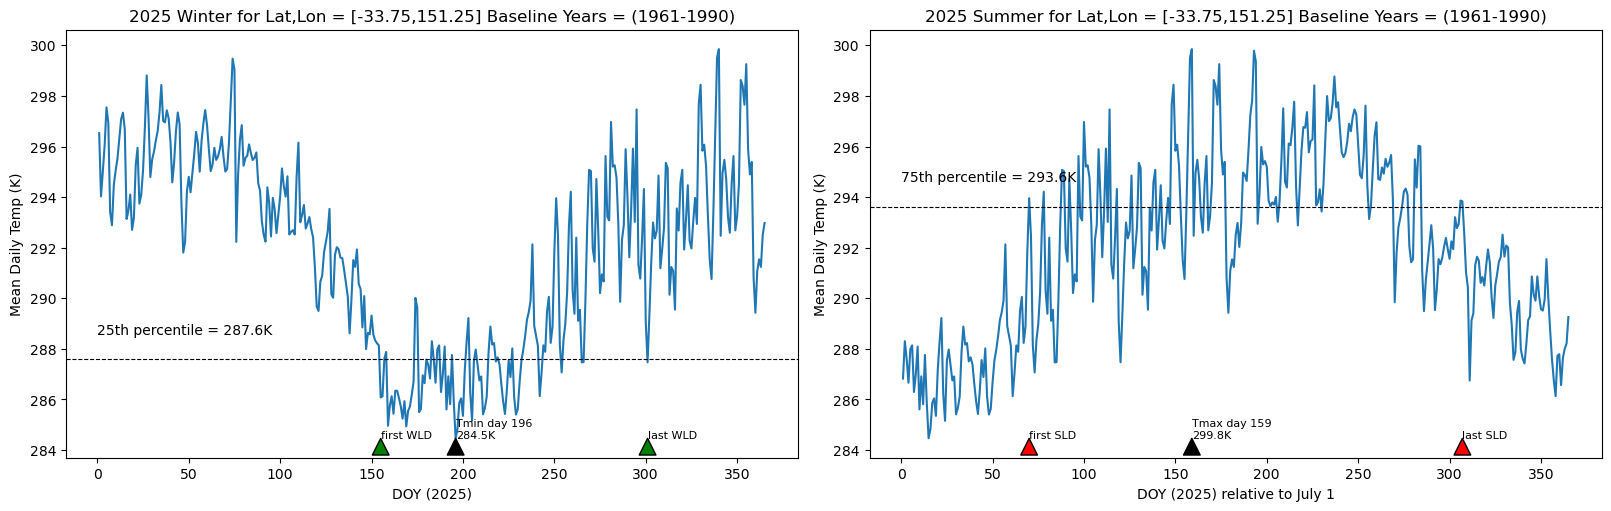

(155, 301, 70, 307, 159, 299.849609375, 196, 284.46746826171875, 65, 131)

In [89]:
# test for Sydney
input_lat = -33 - 52/60 - 4/3600
input_lon = 151.25
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
winter_threshold = c_25.sel(lat=input_lat, lon=input_lon, method="nearest")
summer_threshold = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
first_wld, last_wld, first_sld, last_sld, day_of_max, tmax, day_of_min, tmin, winterlike_days, summerlike_days = WinterSummerDays(curr, nxt, winter_threshold, summer_threshold, True)
first_wld, last_wld, first_sld, last_sld, day_of_max, tmax, day_of_min, tmin, winterlike_days, summerlike_days

### Test Vancouver 2025

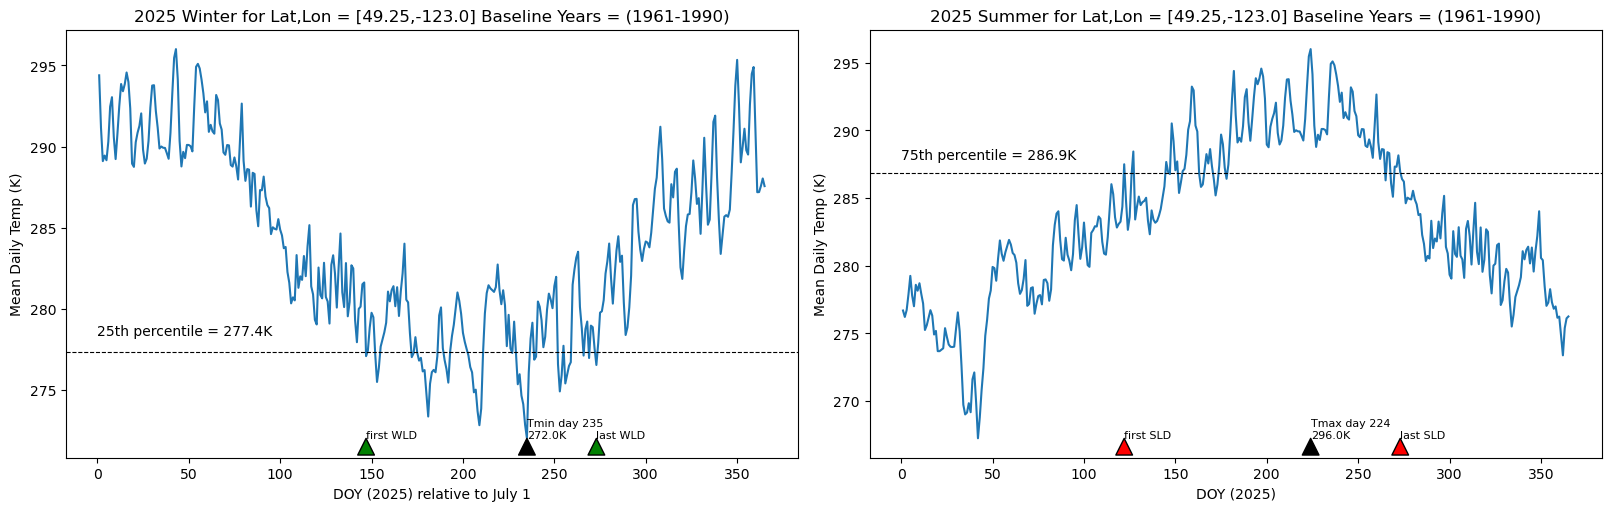

(147, 273, 122, 273, 224, 296.0055847167969, 235, 272.04437255859375, 51, 118)

In [94]:
#test for Vancouver
input_lat = 49.246
input_lon = -123.116
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
winter_threshold = c_25.sel(lat=input_lat, lon=input_lon, method="nearest")
summer_threshold = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
first_wld, last_wld, first_sld, last_sld, day_of_max, tmax, day_of_min, tmin, winterlike_days, summerlike_days = WinterSummerDays(curr, nxt, winter_threshold, summer_threshold, True)
first_wld, last_wld, first_sld, last_sld, day_of_max, tmax, day_of_min, tmin, winterlike_days, summerlike_days

### Vancouver 2005

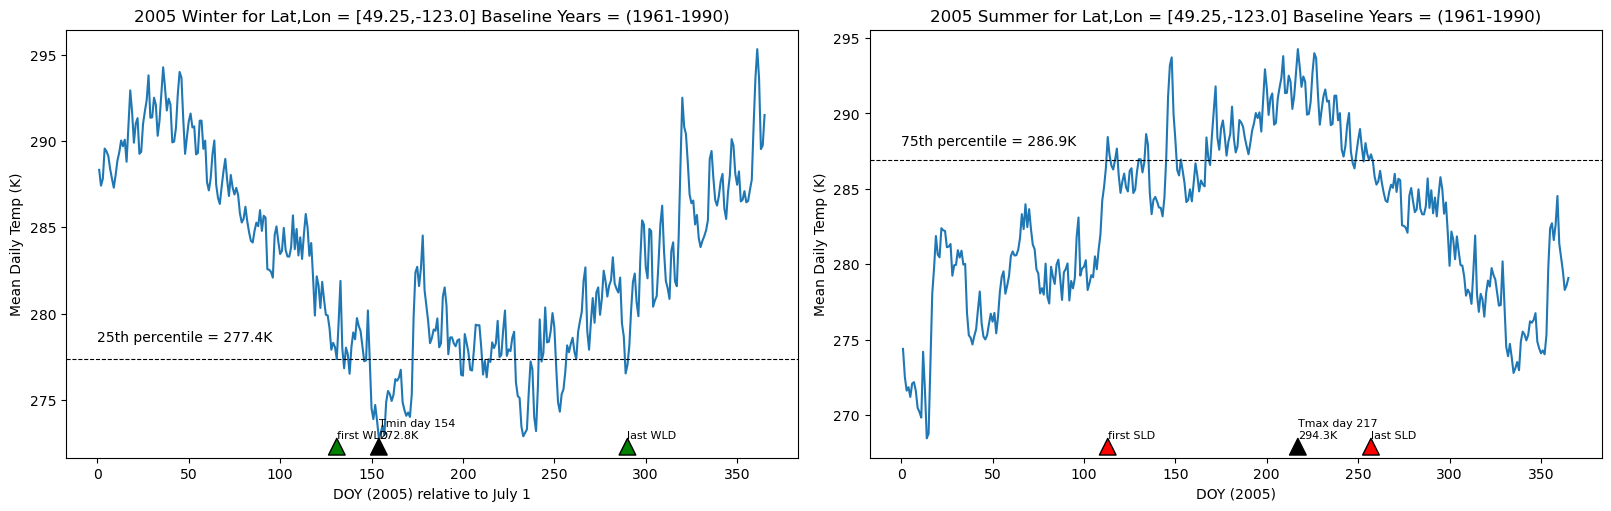

CPU times: user 392 ms, sys: 1.66 s, total: 2.05 s
Wall time: 2.55 s


(131, 290, 113, 257, 217, 294.26165771484375, 154, 272.7848815917969, 61, 102)

In [95]:
%%time
input_year = 2005

# get this year and next year's daily mean t2m data
if input_year <= 1990:
    file_path = '../../../../Data/ERA5-global/Baseline/' + str(input_year) + '/download_daily_mean_2m*.nc'
else:
    file_path = '../../../../Data/ERA5-global/Analysis/' + str(input_year) + '/download_daily_mean_2m*.nc'
ds = xr.open_mfdataset(file_path)

if input_year+1 <= 1990:
    file_path_next = '../../../../Data/ERA5-global/Baseline/' + str(input_year+1) + '/download_daily_mean_2m*.nc'
else:
    file_path_next = '../../../../Data/ERA5-global/Analysis/' + str(input_year+1) + '/download_daily_mean_2m*.nc'
dsnext = xr.open_mfdataset(file_path_next)

# remove leap day by averaging Feb 28 & 29 together before dropping Feb 29
ds = HandleLeapYears(ds)
dsnext = HandleLeapYears(dsnext)

# load into memory to speed up the summer stats processing
ds.load()
dsnext.load()

#test for Vancouver
input_lat = 49.246
input_lon = -123.116
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
winter_threshold = c_25.sel(lat=input_lat, lon=input_lon, method="nearest")
summer_threshold = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
first_wld, last_wld, first_sld, last_sld, day_of_max, tmax, day_of_min, tmin, winterlike_days, summerlike_days = WinterSummerDays(curr, nxt, winter_threshold, summer_threshold, True)
first_wld, last_wld, first_sld, last_sld, day_of_max, tmax, day_of_min, tmin, winterlike_days, summerlike_days

### Vancouver 2021

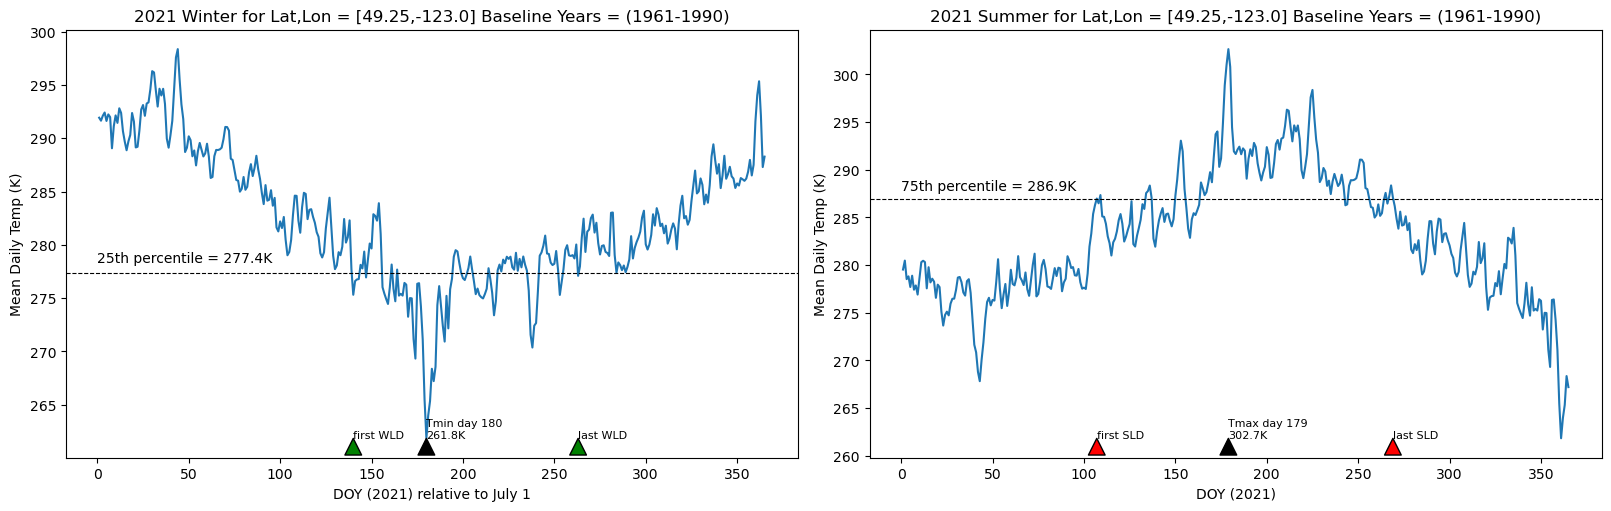

CPU times: user 367 ms, sys: 1.59 s, total: 1.96 s
Wall time: 2.42 s


(140, 263, 107, 269, 179, 302.6524353027344, 180, 261.84100341796875, 66, 107)

In [96]:
%%time
input_year = 2021

# get this year and next year's daily mean t2m data
if input_year <= 1990:
    file_path = '../../../../Data/ERA5-global/Baseline/' + str(input_year) + '/download_daily_mean_2m*.nc'
else:
    file_path = '../../../../Data/ERA5-global/Analysis/' + str(input_year) + '/download_daily_mean_2m*.nc'
ds = xr.open_mfdataset(file_path)

if input_year+1 <= 1990:
    file_path_next = '../../../../Data/ERA5-global/Baseline/' + str(input_year+1) + '/download_daily_mean_2m*.nc'
else:
    file_path_next = '../../../../Data/ERA5-global/Analysis/' + str(input_year+1) + '/download_daily_mean_2m*.nc'
dsnext = xr.open_mfdataset(file_path_next)

# remove leap day by averaging Feb 28 & 29 together before dropping Feb 29
ds = HandleLeapYears(ds)
dsnext = HandleLeapYears(dsnext)

# load into memory to speed up the summer stats processing
ds.load()
dsnext.load()

#test for Vancouver
input_lat = 49.246
input_lon = -123.116
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
winter_threshold = c_25.sel(lat=input_lat, lon=input_lon, method="nearest")
summer_threshold = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
first_wld, last_wld, first_sld, last_sld, day_of_max, tmax, day_of_min, tmin, winterlike_days, summerlike_days = WinterSummerDays(curr, nxt, winter_threshold, summer_threshold, True)
first_wld, last_wld, first_sld, last_sld, day_of_max, tmax, day_of_min, tmin, winterlike_days, summerlike_days

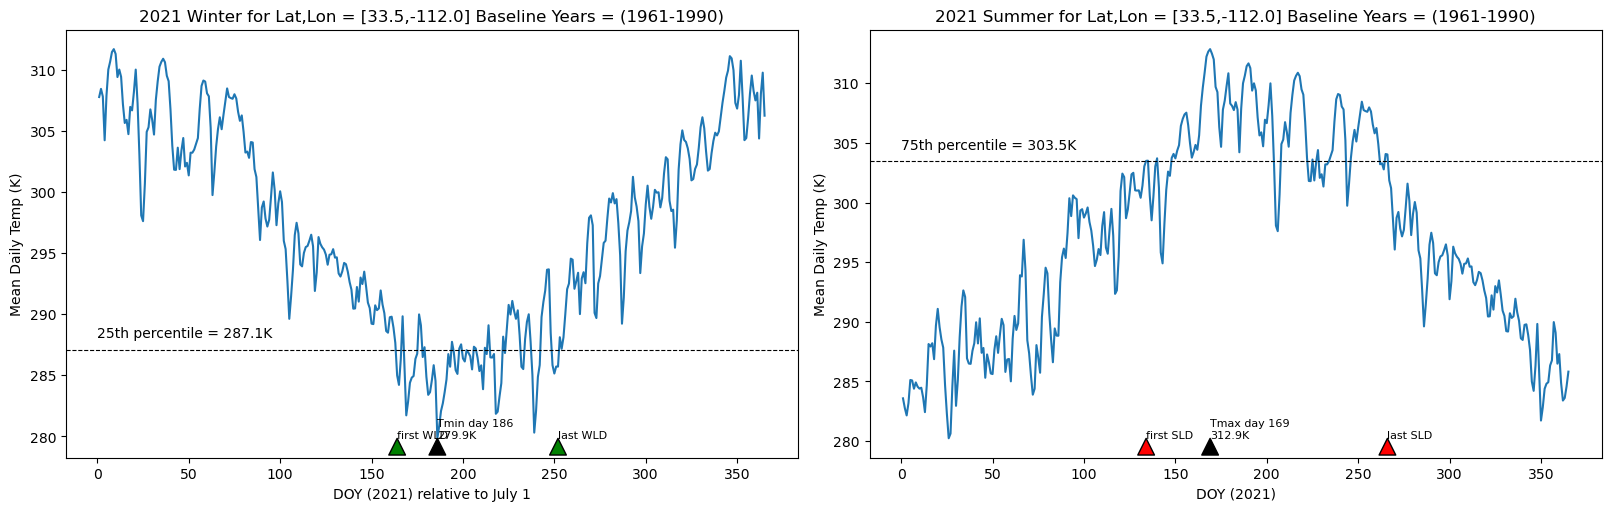

(164, 252, 134, 266, 169, 312.8644104003906, 186, 279.8509826660156, 59, 103)

In [97]:
# Phoenix
input_lat = 33+28/60
input_lon = -112 - 4/60
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
winter_threshold = c_25.sel(lat=input_lat, lon=input_lon, method="nearest")
summer_threshold = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
first_wld, last_wld, first_sld, last_sld, day_of_max, tmax, day_of_min, tmin, winterlike_days, summerlike_days = WinterSummerDays(curr, nxt, winter_threshold, summer_threshold, True)
first_wld, last_wld, first_sld, last_sld, day_of_max, tmax, day_of_min, tmin, winterlike_days, summerlike_days

## ********** NEED to run all years now and then output the 1961-2025 aggregated file for analysis

# **** HERE need to update run all years

## Main Loop: loop through multiple years to generate winter stats

In [114]:
# grid parameters for looping
num_lat = 721
num_lon = 1440

loop_lats = c_25.lat.values[:num_lat]
loop_lons = c_25.lon.values[:num_lon]

In [122]:
# process_yrs = [1990,1991,1992,1993, 1994, 1995, 1996, 1997, 1998, 1999, 2002, 2004, 2005, 2006, 2007, 2008,
#               2009, 2010, 2011, 2012, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
process_yrs = np.arange(1981, 2000,1)

process_yrs

array([1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
       1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999])

In [130]:
%%time

# Runtime: 35 min for 1 year

# loop thru the years in the defined array above
for input_year in process_yrs:

    start = dt.now()

    # get this year and next year's daily mean t2m data
    # 2026-06-15 added coords='minimal' to deal with ERA5 years 2024+ that added "realization" as a variable/coord
    if input_year <= 1990:
        file_path = '../../../../Data/ERA5-global/Baseline/' + str(input_year) + '/download_daily_mean_2m*.nc'
    else:
        file_path = '../../../../Data/ERA5-global/Analysis/' + str(input_year) + '/download_daily_mean_2m*.nc'
    ds = xr.open_mfdataset(file_path, coords='minimal')

    if input_year+1 <= 1990:
        file_path_next = '../../../../Data/ERA5-global/Baseline/' + str(input_year+1) + '/download_daily_mean_2m*.nc'
    else:
        file_path_next = '../../../../Data/ERA5-global/Analysis/' + str(input_year+1) + '/download_daily_mean_2m*.nc'
    dsnext = xr.open_mfdataset(file_path_next, coords='minimal')

    # remove leap day by averaging Feb 28 & 29 together before dropping Feb 29
    ds = HandleLeapYears(ds)
    dsnext = HandleLeapYears(dsnext)

    # load into memory to speed up the winter stats processing
    ds.load()
    dsnext.load()

    # empty data arrays for stats
    first_wld = xr.DataArray(np.zeros((num_lat,num_lon)), 
                                coords=[loop_lats, loop_lons], 
                                dims=['lat','lon'])
    last_wld = xr.DataArray(np.zeros((num_lat,num_lon)), 
                               coords=[loop_lats, loop_lons], 
                               dims=['lat','lon'])
    first_sld = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    last_sld = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    day_of_max = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    t_max = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    day_of_min = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    t_min = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    winterlike_days = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summerlike_days = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    
    # add attributes
    first_wld.attrs["long_name"] = "First day with mean T2m at or below winter threshold for the year (DOY in [1,365])"
    first_wld.attrs["units"] = "Day of year"
    
    last_wld.attrs["long_name"] = "Last day with mean T2m at or below winter threshold for the year (DOY in [1,365])"
    first_wld.attrs["units"] = "Day of year"
    
    first_sld.attrs["long_name"] = "First day with mean T2m at or above summer threshold for the year (DOY in [1,365])"
    first_sld.attrs["units"] = "Day of year"
    
    last_sld.attrs["long_name"] = "Last day with mean T2m at or above summer threshold for the year (DOY in [1,365])"
    first_sld.attrs["units"] = "Day of year"
    
    day_of_max.attrs["long_name"] = "Day of max mean T2m during the year where summer is centered"
    day_of_max.attrs["units"] = "Day of year"
    
    t_max.attrs["long_name"] = "Max T2m during the year where summer is centered"
    t_max.attrs["units"] = "Degrees [K]"
    
    day_of_min.attrs["long_name"] = "Day of min mean T2m during the year where winter is centered"
    day_of_min.attrs["units"] = "Day of year"
    
    t_min.attrs["long_name"] = "Min T2m during the year where winter is centered"
    t_min.attrs["units"] = "Degrees [K]"

    winterlike_days.attrs["long_name"] = "Number of days during the year where winter is centered with mean T2m at or below threshold"
    winterlike_days.attrs["units"] = "Days"

    summerlike_days.attrs["long_name"] = "Number of days during the year where summer is centered with mean T2m at or above threshold"
    summerlike_days.attrs["units"] = "Days"
    

    # loop through all of the lat,lon of interest
    for input_lat in loop_lats:
        for input_lon in loop_lons:
            # get thresholds from c_25 and c_75
            winter_thresh = c_25.sel(lat=input_lat,lon=input_lon)
            summer_thresh = c_75.sel(lat=input_lat,lon=input_lon)
    
            # all the temps for that grid cell over time for this year and next (for SH)
            curr = ds.t2m.sel(lat=input_lat,lon=input_lon) 
            nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon)
    
            # build winter stats for the grid cell and produce the plot if desired (currently False)
            firstwld, lastwld, firstsld, lastsld, dayofmax, tmax, dayofmin, tmin, winterlikedays, summerlikedays = WinterSummerDays(curr, nxt, winter_thresh, summer_thresh, False)
            
            # xarray requires strange indexing in order to replace values by coordinate
            first_wld.loc[input_lat, input_lon] = firstwld
            last_wld.loc[input_lat, input_lon] = lastwld
            first_sld.loc[input_lat, input_lon] = firstsld
            last_sld.loc[input_lat, input_lon] = lastsld
            day_of_max.loc[input_lat, input_lon] = dayofmax
            t_max.loc[input_lat, input_lon] = tmax
            day_of_min.loc[input_lat, input_lon] = dayofmin
            t_min.loc[input_lat, input_lon] = tmin
            winterlike_days.loc[input_lat, input_lon] = winterlikedays
            summerlike_days.loc[input_lat, input_lon] = summerlikedays

    # save it out
    sum_ds = xr.Dataset(data_vars={'FirstWLD':first_wld,
                               'LastWLD':last_wld,
                                   'FirstSLD':first_sld,
                               'LastSLD':last_sld,
                               'DayOfTmax':day_of_max,
                               'Tmax':t_max,
                                   'DayOfTmin':day_of_min,
                               'Tmin':t_min,
                                   'WinterlikeDays':winterlike_days,
                                   'SummerlikeDays':summerlike_days})
    output_path = '../../../../Data/ERA5-global/Analysis/New-Fourier/Seasons/'+str(input_year)+'_summer_winter_days.nc'
    sum_ds.to_netcdf(output_path)


    end = dt.now()
    elapsed = (end-start).total_seconds()/60.0
    print("Time for "+str(input_year)+" :"+str(elapsed)+" min")

Time for 1981 :36.33211391666667 min
Time for 1982 :35.44375778333333 min
Time for 1983 :36.34957681666666 min
Time for 1984 :36.252194716666665 min
Time for 1985 :35.961594633333334 min
Time for 1986 :36.67299096666667 min
Time for 1987 :37.45386883333333 min
Time for 1988 :36.5404353 min
Time for 1989 :35.83208658333333 min
Time for 1990 :35.811508116666666 min
Time for 1991 :36.08642651666666 min
Time for 1992 :36.960419083333335 min
Time for 1993 :35.67415181666667 min
Time for 1994 :35.75984123333333 min
Time for 1995 :36.15198793333333 min
Time for 1996 :36.19255235 min
Time for 1997 :35.4111771 min
Time for 1998 :35.43959821666667 min
Time for 1999 :35.87045086666667 min
CPU times: user 11h 21min 21s, sys: 3min 4s, total: 11h 24min 25s
Wall time: 11h 26min 11s


### Inspect results

In [128]:
# check it
filepath = '../../../../Data/ERA5-global/Analysis/New-Fourier/Seasons/2016_summer_winter_days.nc'
test = xr.open_mfdataset(filepath)
test

<xarray.Dataset> Size: 83MB
Dimensions:         (lat: 721, lon: 1440)
Coordinates:
  * lat             (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon             (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    FirstWLD        (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    LastWLD         (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    FirstSLD        (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    LastSLD         (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    DayOfTmax       (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    Tmax            (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    DayOfTmin       (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    Tmin            (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    WinterlikeDays  (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    SummerlikeDays  (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>

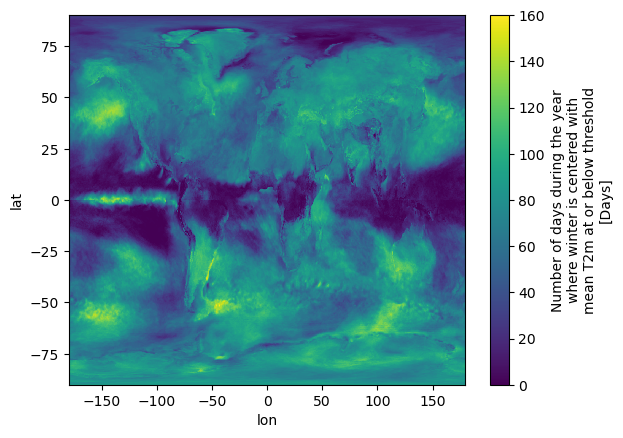

In [129]:
test.WinterlikeDays.plot()